# DOWNLOAD SWOT RASTERS

In this notebook we will create the SWOT mosaics using the SWOT Toolkit developed previously.

In [1]:
%load_ext autoreload
%autoreload 2

import earthaccess
import geopandas as gpd

from swot_toolkit.kml import read_kml_geometry
from swot_toolkit.swot import (
    auth_earthaccess,
    create_mosaic_df,
    download_mosaics,
    get_swot_footprint,
    search_swot_data,
    swot_results_to_df,
)


/workspaces/swot/.venv/lib/python3.12/site-packages/fastkml/config.py:39: UserWarning: Package `lxml` missing. Pretty print will be disabled
  warnings.warn("Package `lxml` missing. Pretty print will be disabled")  # noqa: B028


In [2]:
auth_earthaccess()

# Open the AOI

In [3]:
# Read geometry from a KML file
aois = read_kml_geometry("/data/swot/AOIs/Curua-Una.kml")
if aois is not None:
    aoi = aois[0]

## Search for SWOT Rasters

In [12]:
# Search for products within the AOI and Time frame
results = search_swot_data(
    dataset="Raster_100",
    date_range=("2024-01-01", "2025-11-30"),
    aoi=aoi,
    footprint_filter=True,  # Apply footprint filter to ensure granules intersect with AOI
)

len(results)

23

In [13]:
swot_df = swot_results_to_df(results, drop_duplicates=True)
len(swot_df)

22

In [14]:
mosaic_df = create_mosaic_df(swot_df)
mosaic_df

,,cycle_id,pass_id,tile_id,date_str,vers,item,datetime,date,delta
mosaic_date,tile_name,,,,,,,,,
2024-01-10,186_080F,009,186,080F,20240110T183829,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-10 18:38:29,2024-01-10,0 days
2024-01-31,186_080F,010,186,080F,20240131T152335,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-31 15:23:35,2024-01-31,0 days
2024-02-21,186_080F,011,186,080F,20240221T120840,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-02-21 12:08:40,2024-02-21,0 days
2024-03-13,186_080F,012,186,080F,20240313T085342,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-03-13 08:53:42,2024-03-13,0 days
2024-04-03,186_080F,013,186,080F,20240403T053847,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-04-03 05:38:47,2024-04-03,0 days
2024-04-24,186_080F,014,186,080F,20240424T022353,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-04-24 02:23:53,2024-04-24,0 days
2024-05-14,186_080F,015,186,080F,20240514T230857,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-05-14 23:08:57,2024-05-14,0 days
2024-06-04,186_080F,016,186,080F,20240604T195403,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-06-04 19:54:03,2024-06-04,0 days
2024-06-25,186_080F,017,186,080F,20240625T163906,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-06-25 16:39:06,2024-06-25,0 days


In [15]:
mosaic_df.loc["2024-01-10"]

,cycle_id,pass_id,tile_id,date_str,vers,item,datetime,date,delta
tile_name,,,,,,,,,
186_080F,009,186,080F,20240110T183829,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-10 18:38:29,2024-01-10,0 days


<Axes: >

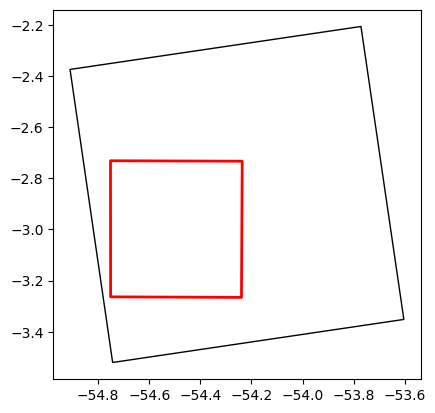

In [17]:
# Plot footprints vs AOI
# Create a DF for the AOI
aoi_df = gpd.GeoDataFrame(geometry=[aoi], crs="EPSG:4326")

mosaic = mosaic_df.loc["2024-01-10"]
footprints = [get_swot_footprint(item)[0] for item in mosaic["item"]]

footprints_df = gpd.GeoDataFrame(geometry=footprints, crs="EPSG:4326")
ax = aoi_df.plot(color="none", edgecolor="red", linewidth=2)
footprints_df.plot(ax=ax, color="none")

In [114]:
# Search for products within the AOI and Time frame
results = search_swot_data(
    dataset="Raster_100",
    date_range=("2024-01-01", "2024-01-31"),
    aoi=(-80, -60, 33, 15),
)


In [115]:
len(results)

10576

In [116]:
swot_df = swot_results_to_df(results, drop_duplicates=True)

In [117]:
unique_tiles_df = swot_df.drop_duplicates(subset=["tile_id"])

In [118]:
unique_tiles_df

,cycle_id,pass_id,tile_id,date_str,tile_name,vers,item,datetime,date
short_id,,,,,,,,,
SWOT_L2_HR_Raster_100m_UTM35H_008_499_048F_20240101T020601,008,499,048F,20240101T020601,499_048F,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-01 02:06:01,2024-01-01
SWOT_L2_HR_Raster_100m_UTM35H_008_499_049F_20240101T020604,008,499,049F,20240101T020604,499_049F,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-01 02:06:04,2024-01-01
SWOT_L2_HR_Raster_100m_UTM35J_008_499_050F_20240101T020624,008,499,050F,20240101T020624,499_050F,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-01 02:06:24,2024-01-01
SWOT_L2_HR_Raster_100m_UTM35J_008_499_051F_20240101T020644,008,499,051F,20240101T020644,499_051F,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-01 02:06:44,2024-01-01
SWOT_L2_HR_Raster_100m_UTM35J_008_499_052F_20240101T020704,008,499,052F,20240101T020704,499_052F,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-01 02:07:04,2024-01-01
...,...,...,...,...,...,...,...,...,...
SWOT_L2_HR_Raster_100m_UTM60W_009_323_138F_20240115T162608,009,323,138F,20240115T162608,323_138F,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-15 16:26:08,2024-01-15
SWOT_L2_HR_Raster_100m_UTM60W_009_416_015F_20240118T232939,009,416,015F,20240118T232939,416_015F,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-18 23:29:39,2024-01-18
SWOT_L2_HR_Raster_100m_UTM60W_009_500_020F_20240121T233253,009,500,020F,20240121T233253,500_020F,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-21 23:32:53,2024-01-21


In [119]:
earthaccess.download(unique_tiles_df["item"].to_list(), local_path="/data/swot/rasters")

QUEUEING TASKS | :   0%|          | 0/109 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/109 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/109 [00:00<?, ?it/s]

['/data/swot/rasters/SWOT_L2_HR_Raster_100m_UTM35H_N_x_x_x_008_499_048F_20240101T020601_20240101T020605_PIC0_01.nc',
 '/data/swot/rasters/SWOT_L2_HR_Raster_100m_UTM35H_N_x_x_x_008_499_049F_20240101T020604_20240101T020625_PIC0_01.nc',
 '/data/swot/rasters/SWOT_L2_HR_Raster_100m_UTM35J_N_x_x_x_008_499_050F_20240101T020624_20240101T020645_PIC0_01.nc',
 '/data/swot/rasters/SWOT_L2_HR_Raster_100m_UTM35J_N_x_x_x_008_499_051F_20240101T020644_20240101T020705_PIC0_01.nc',
 '/data/swot/rasters/SWOT_L2_HR_Raster_100m_UTM35J_N_x_x_x_008_499_052F_20240101T020704_20240101T020725_PIC0_01.nc',
 '/data/swot/rasters/SWOT_L2_HR_Raster_100m_UTM35J_N_x_x_x_008_499_053F_20240101T020724_20240101T020745_PIC0_01.nc',
 '/data/swot/rasters/SWOT_L2_HR_Raster_100m_UTM35J_N_x_x_x_008_499_054F_20240101T020744_20240101T020805_PIC0_01.nc',
 '/data/swot/rasters/SWOT_L2_HR_Raster_100m_UTM35J_N_x_x_x_008_499_055F_20240101T020804_20240101T020825_PIC0_01.nc',
 '/data/swot/rasters/SWOT_L2_HR_Raster_100m_UTM35J_N_x_x_x_008_4

In [47]:
from tqdm.auto import tqdm

for item in tqdm(results, total=len(results)):
    print(f"Processing item: {item['meta']['native-id']}")  # no bbqa: T201
    get_swot_footprint(item)


  0%|          | 0/10576 [00:00<?, ?it/s]

Processing item: SWOT_L2_HR_Raster_100m_UTM35H_N_x_x_x_008_499_048F_20240101T020601_20240101T020605_PIC0_01
Processing item: SWOT_L2_HR_Raster_100m_UTM35H_N_x_x_x_008_499_048F_20240101T020601_20240101T020605_PGC0_01
Processing item: SWOT_L2_HR_Raster_100m_UTM35H_N_x_x_x_008_499_049F_20240101T020604_20240101T020625_PIC0_01
Processing item: SWOT_L2_HR_Raster_100m_UTM35H_N_x_x_x_008_499_049F_20240101T020604_20240101T020625_PGC0_02
Processing item: SWOT_L2_HR_Raster_100m_UTM35J_N_x_x_x_008_499_050F_20240101T020624_20240101T020645_PIC0_01
Processing item: SWOT_L2_HR_Raster_100m_UTM35J_N_x_x_x_008_499_050F_20240101T020624_20240101T020645_PGC0_02
Processing item: SWOT_L2_HR_Raster_100m_UTM35J_N_x_x_x_008_499_051F_20240101T020644_20240101T020705_PIC0_01
Processing item: SWOT_L2_HR_Raster_100m_UTM35J_N_x_x_x_008_499_051F_20240101T020644_20240101T020705_PGC0_02
Processing item: SWOT_L2_HR_Raster_100m_UTM35J_N_x_x_x_008_499_052F_20240101T020704_20240101T020725_PIC0_01
Processing item: SWOT_L2_HR_

In [ ]:
swot_df = swot_results_to_df(results, drop_duplicates=True)
len(swot_df)

In [7]:
mosaic_df = create_mosaic_df(swot_df)
mosaic_df

cycle_id pass_id tile_id         date_str  vers  \
mosaic_date tile_name                                                   
2024-01-11  033_075F       009     033    075F  20240105T072529  PIC0   
            138_018F       009     138    018F  20240109T010822  PIC0   
            186_080F       009     186    080F  20240110T183829  PIC0   
            194_019F       009     194    019F  20240111T010943  PIC0   
            222_021F       009     222    021F  20240112T011054  PIC0   
...                        ...     ...     ...              ...   ...   
2025-04-26  416_015F       031     416    015F  20250422T000123  PIC2   
            472_018F       031     472    018F  20250424T000325  PIC2   
            500_020F       031     500    020F  20250425T000436  PIC2   
            545_136F       031     545    136F  20250426T151840  PIC2   
            573_138F       031     573    138F  20250427T151938  PIC2   

                                                                    item  \
mosaic_date tile_name                                                      
2024-01-11  033_075F   {'meta': {'concept-type': 'granule', 'concept-...   
            138_018F   {'meta': {'concept-type': 'granule', 'concept-...   
            186_080F   {'meta': {'concept-type': 'granule', 'concept-...   
            194_019F   {'meta': {'concept-type': 'granule', 'concept-...   
            222_021F   {'meta': {'concept-type': 'granule', 'concept-...   
...                                                                  ...   
2025-04-26  416_015F   {'meta': {'concept-type': 'granule', 'concept-...   
            472_018F   {'meta': {'concept-type': 'granule', 'concept-...   
            500_020F   {'meta': {'concept-type': 'granule', 'concept-...   
            545_136F   {'meta': {'concept-type': 'granule', 'concept-...   
            573_138F   {'meta': {'concept-type': 'granule', 'concept-...   

                                 datetime        date           delta  
mosaic_date tile_name                                                  
2024-01-11  033_075F  2024-01-05 07:25:29  2024-01-05 0 days 00:00:00  
            138_018F  2024-01-09 01:08:22  2024-01-09 3 days 17:42:53  
            186_080F  2024-01-10 18:38:29  2024-01-10 5 days 11:13:00  
            194_019F  2024-01-11 01:09:43  2024-01-11 5 days 17:44:14  
            222_021F  2024-01-12 01:10:54  2024-01-12 6 days 17:45:25  
...                                   ...         ...             ...  
2025-04-26  416_015F  2025-04-22 00:01:23  2025-04-22 7 days 04:40:55  
            472_018F  2025-04-24 00:03:25  2025-04-24 5 days 04:38:53  
            500_020F  2025-04-25 00:04:36  2025-04-25 4 days 04:37:42  
            545_136F  2025-04-26 15:18:40  2025-04-26 2 days 13:23:38  
            573_138F  2025-04-27 15:19:38  2025-04-27 1 days 13:22:40  

[213 rows x 9 columns]

In [13]:
# Plot footprints vs AOI
# Create a DF for the AOI
aoi_df = gpd.GeoDataFrame(geometry=[aoi], crs="EPSG:4326")

mosaic = mosaic_df.loc["2024-01-11"]
footprints = {get_swot_footprint(item)[1]: get_swot_footprint(item)[0] for item in mosaic["item"]}


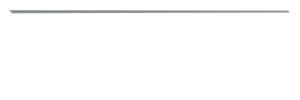

In [36]:
footprints["018F"]

In [ ]:
360 - 177.651

182.349

In [32]:
results[-1]["umm"]

{'TemporalExtent': {'RangeDateTime': {'EndingDateTime': '2025-05-02T22:25:31.272Z',
   'BeginningDateTime': '2025-05-02T22:25:10.139Z'}},
 'GranuleUR': 'SWOT_L2_HR_Raster_100m_UTM01W_N_x_x_x_032_138_018F_20250502T222510_20250502T222531_PIC2_01',
 'AdditionalAttributes': [{'Values': ['034L',
    '035L',
    '036L',
    '037L',
    '034R',
    '035R',
    '036R',
    '037R'],
   'Name': 'TILE'}],
 'MeasuredParameters': [{'QAStats': {'QAPercentMissingData': 0,
    'QAPercentOutOfBoundsData': 0},
   'ParameterName': 'N/A'}],
 'SpatialExtent': {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -180,
      'SouthBoundingCoordinate': -90,
      'EastBoundingCoordinate': 180,
      'NorthBoundingCoordinate': 90}]},
   'Track': {'Cycle': 32,
    'Passes': [{'Pass': 138,
      'Tiles': ['034L',
       '035L',
       '036L',
       '037L',
       '034R',
       '035R',
       '036R',
       '037R']}]}}},
 'ProviderDates': [{'Type': 'Insert', 'Date': '2025-

In [18]:
results[-1]

Collection: {'Version': '2.0', 'ShortName': 'SWOT_L2_HR_Raster_2.0'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -180, 'SouthBoundingCoordinate': -90, 'EastBoundingCoordinate': 180, 'NorthBoundingCoordinate': 90}]}, 'Track': {'Cycle': 32, 'Passes': [{'Pass': 138, 'Tiles': ['034L', '035L', '036L', '037L', '034R', '035R', '036R', '037R']}]}}}
Temporal coverage: {'RangeDateTime': {'EndingDateTime': '2025-05-02T22:25:31.272Z', 'BeginningDateTime': '2025-05-02T22:25:10.139Z'}}
Size(MB): 67.47187042236328
Data: ['https://archive.swot.podaac.earthdata.nasa.gov/podaac-swot-ops-cumulus-protected/SWOT_L2_HR_Raster_2.0/SWOT_L2_HR_Raster_100m_UTM01W_N_x_x_x_032_138_018F_20250502T222510_20250502T222531_PIC2_01.nc']

In [23]:
files = earthaccess.open([results[-1]])

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
import xarray as xr

ds = xr.open_dataset(files[0])

In [31]:
ds

<xarray.Dataset> Size: 598MB
Dimensions:                  (y: 1746, x: 1746)
Coordinates:
  * x                        (x) float64 14kB 3.605e+05 3.606e+05 ... 5.35e+05
  * y                        (y) float64 14kB 7.264e+06 7.264e+06 ... 7.439e+06
Data variables: (12/39)
    crs                      object 8B ...
    longitude                (y, x) float64 24MB ...
    latitude                 (y, x) float64 24MB ...
    wse                      (y, x) float32 12MB ...
    wse_qual                 (y, x) float32 12MB ...
    wse_qual_bitwise         (y, x) float64 24MB ...
    ...                       ...
    load_tide_fes            (y, x) float32 12MB ...
    load_tide_got            (y, x) float32 12MB ...
    pole_tide                (y, x) float32 12MB ...
    model_dry_tropo_cor      (y, x) float32 12MB ...
    model_wet_tropo_cor      (y, x) float32 12MB ...
    iono_cor_gim_ka          (y, x) float32 12MB ...
Attributes: (12/49)
    Conventions:                   CF-1.7
    title:                         Level 2 KaRIn High Rate Raster Data Product
    source:                        Ka-band radar interferometer
    history:                       2025-05-05T23:29:43Z : Creation
    platform:                      SWOT
    references:                    V1.3.1
    ...                            ...
    x_min:                         360500.0
    x_max:                         535000.0
    y_min:                         7264200.0
    y_max:                         7438700.0
    institution:                   CNES
    product_version:               01

In [37]:
footprint_coords = [
    (ds.attrs["left_first_longitude"], ds.attrs["left_first_latitude"]),  # bottom-left
    (ds.attrs["right_first_longitude"], ds.attrs["right_first_latitude"]),  # bottom-right
    (ds.attrs["right_last_longitude"], ds.attrs["right_last_latitude"]),  # top-right
    (ds.attrs["left_last_longitude"], ds.attrs["left_last_latitude"]),  # top-left
    (ds.attrs["left_first_longitude"], ds.attrs["left_first_latitude"]),
]

In [ ]:
footprint_coords = [
    (coords[0] if coords[0] > 0 else 360 + coords[0], coords[1]) for coords in footprint_coords
]

In [41]:
footprint_coords

[(np.float64(182.349063521756), np.float64(67.06435511900916)),
 (np.float64(179.86858706970273), np.float64(66.46591368402517)),
 (np.float64(181.3508810323819), np.float64(65.4916036405111)),
 (np.float64(183.77302776727757), np.float64(66.06454155527895)),
 (np.float64(182.349063521756), np.float64(67.06435511900916))]

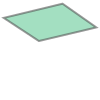

In [ ]:
from shapely.geometry import Polygon

Polygon(footprint_coords)

In [14]:
footprints

{'075F': <POLYGON ((-55.146 -3.352, -54.006 -3.52, -53.839 -2.375, -54.978 -2.207, -5...>,
 '018F': <POLYGON ((-177.651 67.064, 179.869 66.466, -178.649 65.492, -176.227 66.065...>,
 '080F': <POLYGON ((-53.772 -2.207, -54.91 -2.375, -54.743 -3.52, -53.604 -3.352, -53...>,
 '019F': <POLYGON ((178.842 66.065, 176.419 65.492, 177.788 64.502, -179.849 65.051, ...>,
 '021F': <POLYGON ((178.893 64.026, 176.588 63.499, 177.762 62.484, -179.991 62.99, 1...>,
 '137F': <POLYGON ((179.669 66.065, -177.909 65.492, -176.426 66.466, -178.907 67.064...>,
 '138F': <POLYGON ((176.162 67.064, 178.642 66.466, -179.749 67.423, 177.714 68.049, ...>}

<Axes: >

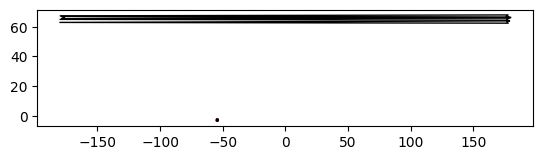

In [9]:
footprints_df = gpd.GeoDataFrame(geometry=footprints, crs="EPSG:4326")
ax = aoi_df.plot(color="none", edgecolor="red", linewidth=2)
footprints_df.plot(ax=ax, color="none")

<Axes: >

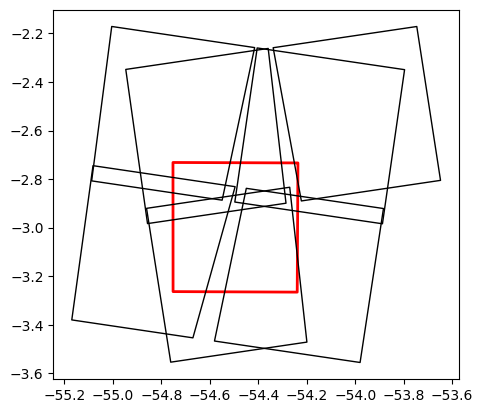

In [ ]:
footprints_df = gpd.GeoDataFrame(geometry=footprints, crs="EPSG:4326")
ax = aoi_df.plot(color="none", edgecolor="red", linewidth=2)
footprints_df.plot(ax=ax, color="none")

In [44]:
item = results[0]

In [45]:
files = earthaccess.open([item], "/data/swot/downloads")

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

In [46]:
files

[<File-like object HTTPFileSystem, https://archive.swot.podaac.earthdata.nasa.gov/podaac-swot-ops-cumulus-protected/SWOT_L2_HR_Raster_2.0/SWOT_L2_HR_Raster_100m_UTM10T_N_x_x_x_474_013_114F_20230329T085242_20230329T085303_PGC0_01.nc>]

In [50]:
results[0]

Collection: {'Version': '2.0', 'ShortName': 'SWOT_L2_HR_Raster_2.0'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 40.83232481855357, 'Longitude': -124.62463249949994}, {'Latitude': 40.83232481855357, 'Longitude': -122.77206801683361}, {'Latitude': 42.224186853462356, 'Longitude': -122.77206801683361}, {'Latitude': 42.224186853462356, 'Longitude': -124.62463249949994}, {'Latitude': 40.83232481855357, 'Longitude': -124.62463249949994}]}}], 'BoundingRectangles': [{'WestBoundingCoordinate': -124.62463249949994, 'SouthBoundingCoordinate': 40.83232481855357, 'EastBoundingCoordinate': -122.77206801683361, 'NorthBoundingCoordinate': 42.224186853462356}]}, 'Track': {'Cycle': 474, 'Passes': [{'Pass': 13, 'Tiles': ['226L', '227L', '228L', '229L', '226R', '227R', '228R', '229R']}]}}}
Temporal coverage: {'RangeDateTime': {'EndingDateTime': '2023-03-29T08:53:03.863Z', 'BeginningDateTime': '2023-03-29T08:52:42.890Z'}}
Size(MB): 59.67605113983154
Data: ['https://archive.swot.podaac.earthdata.nasa.gov/podaac-swot-ops-cumulus-protected/SWOT_L2_HR_Raster_2.0/SWOT_L2_HR_Raster_100m_UTM10T_N_x_x_x_474_013_114F_20230329T085242_20230329T085303_PGC0_01.nc']

In [53]:
item.values()

dict_values([{'concept-type': 'granule', 'concept-id': 'G2911037500-POCLOUD', 'revision-id': 1, 'native-id': 'SWOT_L2_HR_Raster_100m_UTM10T_N_x_x_x_474_013_114F_20230329T085242_20230329T085303_PGC0_01', 'collection-concept-id': 'C2799438271-POCLOUD', 'provider-id': 'POCLOUD', 'format': 'application/vnd.nasa.cmr.umm+json', 'revision-date': '2024-03-27T18:27:20.320Z'}, {'TemporalExtent': {'RangeDateTime': {'EndingDateTime': '2023-03-29T08:53:03.863Z', 'BeginningDateTime': '2023-03-29T08:52:42.890Z'}}, 'GranuleUR': 'SWOT_L2_HR_Raster_100m_UTM10T_N_x_x_x_474_013_114F_20230329T085242_20230329T085303_PGC0_01', 'AdditionalAttributes': [{'Values': ['226L', '227L', '228L', '229L', '226R', '227R', '228R', '229R'], 'Name': 'TILE'}], 'MeasuredParameters': [{'QAStats': {'QAPercentMissingData': 0, 'QAPercentOutOfBoundsData': 0}, 'ParameterName': 'N/A'}], 'SpatialExtent': {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 40.83232481855357, 'Longitude': -124

In [54]:
item["umm"]["SpatialExtent"]["HorizontalSpatialDomain"]

{'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 40.83232481855357,
       'Longitude': -124.62463249949994},
      {'Latitude': 40.83232481855357, 'Longitude': -122.77206801683361},
      {'Latitude': 42.224186853462356, 'Longitude': -122.77206801683361},
      {'Latitude': 42.224186853462356, 'Longitude': -124.62463249949994},
      {'Latitude': 40.83232481855357, 'Longitude': -124.62463249949994}]}}],
  'BoundingRectangles': [{'WestBoundingCoordinate': -124.62463249949994,
    'SouthBoundingCoordinate': 40.83232481855357,
    'EastBoundingCoordinate': -122.77206801683361,
    'NorthBoundingCoordinate': 42.224186853462356}]},
 'Track': {'Cycle': 474,
  'Passes': [{'Pass': 13,
    'Tiles': ['226L',
     '227L',
     '228L',
     '229L',
     '226R',
     '227R',
     '228R',
     '229R']}]}}

In [56]:
swot_item = item

In [59]:
"Raster" in swot_item["meta"]["native-id"]

True

In [64]:
geometry = swot_item["umm"]["SpatialExtent"]["HorizontalSpatialDomain"]["Geometry"]
points = geometry["GPolygons"][0]["Boundary"]["Points"]

In [70]:
from shapely.geometry import Polygon


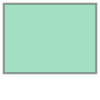

In [69]:
pts = [(p["Longitude"], p["Latitude"]) for p in points]
Polygon(pts)

In [81]:
import geopandas as gpd

In [ ]:
gpd.GeoDataFrame(geometry=[Polygon(pts)], crs="EPSG:4326").to_parquet(
    "/data/swot/footprints/test.parquet"
)

In [55]:
item["meta"]

{'concept-type': 'granule',
 'concept-id': 'G2911037500-POCLOUD',
 'revision-id': 1,
 'native-id': 'SWOT_L2_HR_Raster_100m_UTM10T_N_x_x_x_474_013_114F_20230329T085242_20230329T085303_PGC0_01',
 'collection-concept-id': 'C2799438271-POCLOUD',
 'provider-id': 'POCLOUD',
 'format': 'application/vnd.nasa.cmr.umm+json',
 'revision-date': '2024-03-27T18:27:20.320Z'}

In [47]:
import xarray as xr

In [71]:
ds = xr.open_dataset(files[0])

In [75]:
type(ds.attrs["left_first_longitude"])

numpy.float64

In [ ]:
footprint_coords = [
    (ds.attrs["left_first_longitude"], ds.attrs["left_first_latitude"]),  # bottom-left
    (ds.attrs["right_first_longitude"], ds.attrs["right_first_latitude"]),  # bottom-right
    (ds.attrs["right_last_longitude"], ds.attrs["right_last_latitude"]),  # top-right
    (ds.attrs["left_last_longitude"], ds.attrs["left_last_latitude"]),  # top-left
    (ds.attrs["left_first_longitude"], ds.attrs["left_first_latitude"]),
]

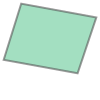

In [78]:
Polygon(footprint_coords)

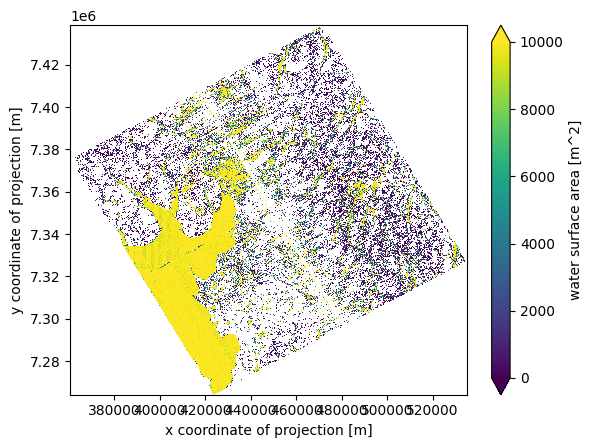

In [40]:
ds["water_area"].plot.imshow(vmin=0, vmax=10000)

In [43]:
item["umm"]

{'TemporalExtent': {'RangeDateTime': {'EndingDateTime': '2024-01-05T07:25:50.895Z',
   'BeginningDateTime': '2024-01-05T07:25:29.809Z'}},
 'GranuleUR': 'SWOT_L2_HR_Raster_100m_UTM21M_N_x_x_x_009_033_075F_20240105T072529_20240105T072550_PIC0_01',
 'AdditionalAttributes': [{'Values': ['148L',
    '149L',
    '150L',
    '151L',
    '148R',
    '149R',
    '150R',
    '151R'],
   'Name': 'TILE'}],
 'MeasuredParameters': [{'QAStats': {'QAPercentMissingData': 0,
    'QAPercentOutOfBoundsData': 0},
   'ParameterName': 'N/A'}],
 'SpatialExtent': {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': -3.519923595260316,
         'Longitude': -55.14578554225298},
        {'Latitude': -3.519923595260316, 'Longitude': -53.83938029472503},
        {'Latitude': -2.2066260584520814, 'Longitude': -53.83938029472503},
        {'Latitude': -2.2066260584520814, 'Longitude': -55.14578554225298},
        {'Latitude': -3.519923595260316, 'Longitude': -55.1457855422529

In [ ]:
files[0]

<File-like object HTTPFileSystem, https://archive.swot.podaac.earthdata.nasa.gov/podaac-swot-ops-cumulus-protected/SWOT_L2_HR_Raster_2.0/SWOT_L2_HR_Raster_100m_UTM21M_N_x_x_x_009_033_075F_20240105T072529_20240105T072550_PIC0_01.nc>

In [ ]:
item["meta"]

{'concept-type': 'granule',
 'concept-id': 'G2832529605-POCLOUD',
 'revision-id': 4,
 'native-id': 'SWOT_L2_HR_Raster_100m_UTM21M_N_x_x_x_009_033_075F_20240105T072529_20240105T072550_PIC0_01',
 'collection-concept-id': 'C2799438271-POCLOUD',
 'provider-id': 'POCLOUD',
 'format': 'application/vnd.nasa.cmr.umm+json',
 'revision-date': '2024-03-05T15:12:37.842Z'}

In [16]:
item["umm"]

{'TemporalExtent': {'RangeDateTime': {'EndingDateTime': '2024-01-05T07:25:50.895Z',
   'BeginningDateTime': '2024-01-05T07:25:29.809Z'}},
 'GranuleUR': 'SWOT_L2_HR_Raster_100m_UTM21M_N_x_x_x_009_033_075F_20240105T072529_20240105T072550_PIC0_01',
 'AdditionalAttributes': [{'Values': ['148L',
    '149L',
    '150L',
    '151L',
    '148R',
    '149R',
    '150R',
    '151R'],
   'Name': 'TILE'}],
 'MeasuredParameters': [{'QAStats': {'QAPercentMissingData': 0,
    'QAPercentOutOfBoundsData': 0},
   'ParameterName': 'N/A'}],
 'SpatialExtent': {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': -3.519923595260316,
         'Longitude': -55.14578554225298},
        {'Latitude': -3.519923595260316, 'Longitude': -53.83938029472503},
        {'Latitude': -2.2066260584520814, 'Longitude': -53.83938029472503},
        {'Latitude': -2.2066260584520814, 'Longitude': -55.14578554225298},
        {'Latitude': -3.519923595260316, 'Longitude': -55.1457855422529

In [12]:
swot_df = swot_results_to_df(results, drop_duplicates=True)
swot_df

DateParseError: Unknown datetime string format, unable to parse: x, at position 0

In [ ]:
mosaic_df = create_mosaic_df(swot_df)

In [8]:
mosaic_df.loc["2024-01-07"]

,cycle_id,pass_id,tile_id,date_str,vers,item,datetime,date,delta
tile_name,,,,,,,,,
033_149L,009,033,149L,20240105T072529,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-05 07:25:29,2024-01-05,0 days 00:00:00
033_149R,009,033,149R,20240105T072529,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-05 07:25:29,2024-01-05,0 days 00:00:00
033_150L,009,033,150L,20240105T072539,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-05 07:25:39,2024-01-05,0 days 00:00:10
033_150R,009,033,150R,20240105T072539,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-05 07:25:39,2024-01-05,0 days 00:00:10
186_159L,009,186,159L,20240110T183829,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-10 18:38:29,2024-01-10,5 days 11:13:00
186_159R,009,186,159R,20240110T183829,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-10 18:38:29,2024-01-10,5 days 11:13:00
186_160R,009,186,160R,20240110T183839,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-10 18:38:39,2024-01-10,5 days 11:13:10


In [13]:
mosaic_df.index.get_level_values(0).unique()

DatetimeIndex(['2024-01-07', '2024-01-28', '2024-02-18', '2024-03-10',
               '2024-03-31', '2024-04-20', '2024-05-11', '2024-06-02',
               '2024-06-22', '2024-07-13', '2024-08-24', '2024-09-14',
               '2024-10-01', '2024-10-25', '2024-12-06', '2024-12-27',
               '2025-01-17', '2025-02-07', '2025-02-27', '2025-03-20',
               '2025-04-10', '2025-04-29'],
              dtype='datetime64[ns]', name='mosaic_date', freq=None)

In [9]:
mosaics = download_mosaics(
    mosaic_df,
    aoi=aoi,
    local_path="/data/swot/mosaics",
)

QUEUEING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/7 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

...

PROCESSING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/7 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]

<Axes: >

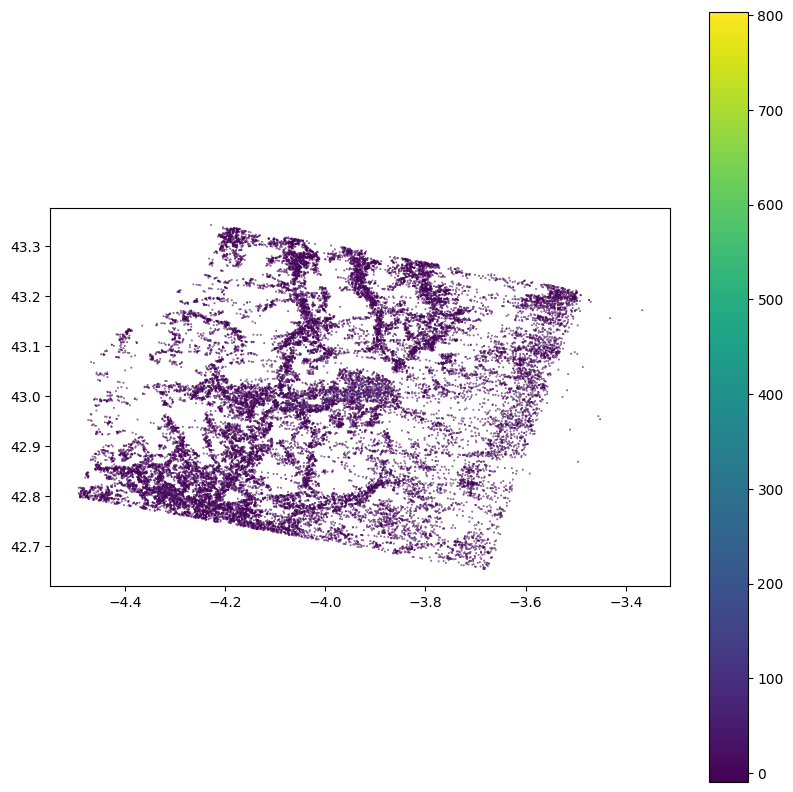

In [ ]:
from matplotlib.colors import ListedColormap

# Create a custom colormap to display the classes
custom_colors = ListedColormap(
    ["navy", "green", "darkgreen", "red", "orange", "blue", "royalblue"]
)

# convert the classes from integer to categories
classes = {
    1: "land",
    2: "land_near_water",
    3: "water_near_land",
    4: "open_water",
    5: "dark_water",
    6: "low_coh_water_near_land",
    7: "open_low_coh_water",
}

gdf["classes"] = gdf["classification"].map(classes).astype("category")

# apply Log to the coherent_power to better visualization
gdf["log_power"] = np.log(gdf["coherent_power"])

gdf.sample(30000).plot(markersize=0.1, column="sig0", figsize=(10, 10), legend=True)